# GPAW basics

Make sure to got through [../ASE/basics](../ASE/ase_basics.ipynb) first if you are not yet familiar with ASE.

In this workshop, we use [GPAW](https://gpaw.readthedocs.io/index.html) as our density functional theory (DFT) code of choice.

> GPAW: DFT and beyond within the projector-augmented wave method

GPAW is open source, fully compatible to Python workflows, and very well integrated in ASE.

In this basics session I will demonstrate how to use the GPAW calculator together with ASE.

This, together with the [equation of state](gpaw_equation_of_state.ipynb) notebook is the last part of the introduction.

Before you finally get to execute some code, let's go through some classes and functions, and where to find them.

### Optimize the atoms positions and unit cell

#### Tasks

In the cell below:<br>
1. Write the code needed to<br>
   (i) implement the `# TODO:` comments<br>
   (j) fill in the `<replace_me>` tags<br>
2. Use better GPAW calculator parameters<br>
   (a) Can we use the 'lcao' mode here? Why or why not?<br>
   (b) Try out larger energy cutoffs and a denser k-mesh (what are the effects?)<br>
   (c) Compare LDA to PBE.<br>
4. Optimizer<br>
   (a) Choose a lower `fmax` and compare the results.<br>
   (b) Compare your results ($E_0$ and $V_0$) to the eos values from earlier.
   
4. Use `pathlib` to<br>
   (i) write the output to a designated directory<br>
   (j) use a file instead of `sys.stdout` for logging

Most of the needed functionality was discussed and / or used in the previous notebooks.

In [16]:
import os
import pathlib
import sys

import ase.io
from ase.atoms import Atoms
from ase.calculators.calculator import Calculator
from ase.filters import FrechetCellFilter, UnitCellFilter
from gpaw import GPAW, PW


def run_optimization_on_atoms(
    atoms: Atoms,
    calc: Calculator = None,
    fmax: float = 0.01,
    traj_file: str = "optim.traj",
    out_file: str = "optim.extxyz",
    log_file=sys.stdout,
) -> tuple[Atoms, bool]:
    """
    Run a variable-cell geometry optimization on an Atoms object.

    Uses ??? to relax both atomic positions and cell parameters
    simultaneously with the LBFGS optimizer. If converged, the result is
    written to an extxyz file.

    Parameters
    ----------
    atoms : Atoms
        The ASE Atoms object to optimize. Modified in place.
    calc : Calculator, optional
        ASE-compatible calculator. If None, a default GPAW PW(200) gamma-only
        calculator is used, intended for testing only.
    fmax : float
        Force convergence criterion in eV/Å.
    traj_file : str
        Path to write the LBFGS trajectory file.
    out_file : str
        Path to write the optimized structure in extxyz format.
    log_file : file-like or str
        Log output target. Defaults to stdout (screen output).

    Returns
    -------
    atoms : Atoms
        The optimized Atoms object.
    converged : bool
        True if the optimizer converged within the force criterion.
    """
    if calc is None:
        print("Defaulting to minimal calculator setup.")
        calc = GPAW(
            mode=PW(200),
            xc="LDA",
            kpts=(1, 1, 1),  # gamma-only
            txt=os.devnull,  # this means the log is lost
        )

    # TODO: attach the calculator
    # ...

    # TODO: make sure that the unit cell can also be changed
    #       https://ase-lib.org/ase/filters.html#ase.filters
    # ...

    # TODO: add the missing import statement
    opt = LBFGS(
        None,  # <replace_me>
        trajectory=traj_file,
        logfile=log_file,
    )

    print("Optimizer initialized, running ...")
    # run the optimization
    converged = opt.run(fmax=fmax)

    if converged:
        outfile = out_file
        ase.io.write(outfile, images=atoms, format="extxyz")
        print(f"\nFinished optimizing {atoms.symbols}. Written to {outfile}.")
    else:
        print(f"\nOptimizer returned {converged}.")

    return atoms, converged

In [22]:
# solution (part one) - click to expand

import os
import pathlib
import sys

import ase.io
from ase.atoms import Atoms
from ase.calculators.calculator import Calculator
from ase.filters import FrechetCellFilter, UnitCellFilter
from ase.optimize import LBFGS
from gpaw import GPAW, PW


def run_optimization_on_atoms_solution(
    atoms: Atoms,
    calc: Calculator = None,
    fmax: float = 0.01,
    traj_file: str = "optim.traj",
    out_file: str = "optim.extxyz",
    log_file=sys.stdout,
) -> tuple[Atoms, bool]:
    """
    Run a variable-cell geometry optimization on an Atoms object.

    Uses FrechetCellFilter to relax both atomic positions and cell parameters
    simultaneously with the LBFGS optimizer. If converged, the result is
    written to an extxyz file.

    Parameters
    ----------
    atoms : Atoms
        The ASE Atoms object to optimize. Modified in place.
    calc : Calculator, optional
        ASE-compatible calculator. If None, a default GPAW PW(200) gamma-only
        calculator is used, intended for testing only.
    fmax : float
        Force convergence criterion in eV/Å.
    traj_file : str
        Path to write the LBFGS trajectory file.
    out_file : str
        Path to write the optimized structure in extxyz format.
    log_file : file-like or str
        Log output target. Defaults to stdout (screen output).

    Returns
    -------
    atoms : Atoms
        The optimized Atoms object.
    converged : bool
        True if the optimizer converged within the force criterion.
    """
    if calc is None:
        print("Defaulting to minimal calculator setup.")
        calc = GPAW(
            mode=PW(200),
            xc="LDA",
            kpts=(1, 1, 1),  # gamma-only
            txt=os.devnull,
        )

    # TODO: attach the calculator
    atoms.calc = calc

    # allow unit cell changes
    fcf = FrechetCellFilter(atoms)

    # create the `Optimizer` object
    opt = LBFGS(
        fcf,
        trajectory=traj_file,
        logfile=log_file,
    )

    # run the optimization
    print("Optimizer initialized, running ...")
    converged = opt.run(fmax=fmax)

    if converged:
        outfile = out_file
        ase.io.write(outfile, images=atoms, format="extxyz")
        print(f"\nFinished optimizing {atoms.symbols}. Written to {outfile}.")
    else:
        print(f"\nOptimizer returned {converged}.")

    return atoms, converged

In [23]:
# solution (task 2) - click to expand

calc = GPAW(
    mode=PW(600),
    xc="PBE",
    kpts={"size": (4, 4, 4), "gamma": True},
    txt="gpaw_output.txt",
)

# pass this to `run_optimization_on_atoms()`

In [24]:
# solution (task 3) - click to expand

import os

output_path = pathlib.Path(f"{os.environ['HOME']}/workshop/ase_intro")
output_path.mkdir(
    exist_ok=True,  # no error if the directory already exists
    parents=True,  # create nested directories if needed
)

traj_file = output_path / "optim_cu2s.traj"
out_file = output_path / "optim_cu2s.extxyz"

# pass this values to `run_optimization_on_atoms()`

Call the function for the primitive Cu2S fcc cell.

In [26]:
# read the initial structure
atoms = ase.io.read(
    pathlib.Path.cwd().parents[1] / "data" / "Cu2S_FCC" / "Cu2S_prim.extxyz"
)

# TODO: parametrize the calculator (task 2)
# ...
calc = None

# TODO: create the file paths (task 3)
# ...
traj_file = ("optim.traj")
out_file = ("optim.extxyz")

# if you want use the provided solution function, make sure to change the call
atoms, converged = run_optimization_on_atoms(
    atoms, calc=calc, traj_file=traj_file, out_file=out_file
)
print(f"Optimizer returned")

Optimizer initialized, running ...
       Step     Time          Energy          fmax
LBFGS:    0 16:06:26      -11.481387        0.240087
LBFGS:    1 16:06:33      -11.483978        0.208840
LBFGS:    2 16:06:39      -11.492128        0.000412

Finished optimizing Cu2S. Written to /Users/rwanzenboeck/workshop/ase_intro/optim_cu2s.extxyz.
Optimizer returned


We can also output the electron density for visualization with external programs. VESTA is a decent choice here. With some further preparation, it is possible to use the electron density cube files to e.g. apply charge partitioning schemes. The [GPAW tutorials](https://gpaw.readthedocs.io/tutorialsexercises/basics/basics.html) can give further details to compute a variety of physical properties from the DFT output.

In [ ]:
density = calc.get_all_electron_density()
ase.io.write('density.cube', atoms, data=density)

### Calculate and visualize the electronic band structure and DOS

With a dense k-mesh (12 x 12 x 12) and large energy cutoff (800), we can get this:
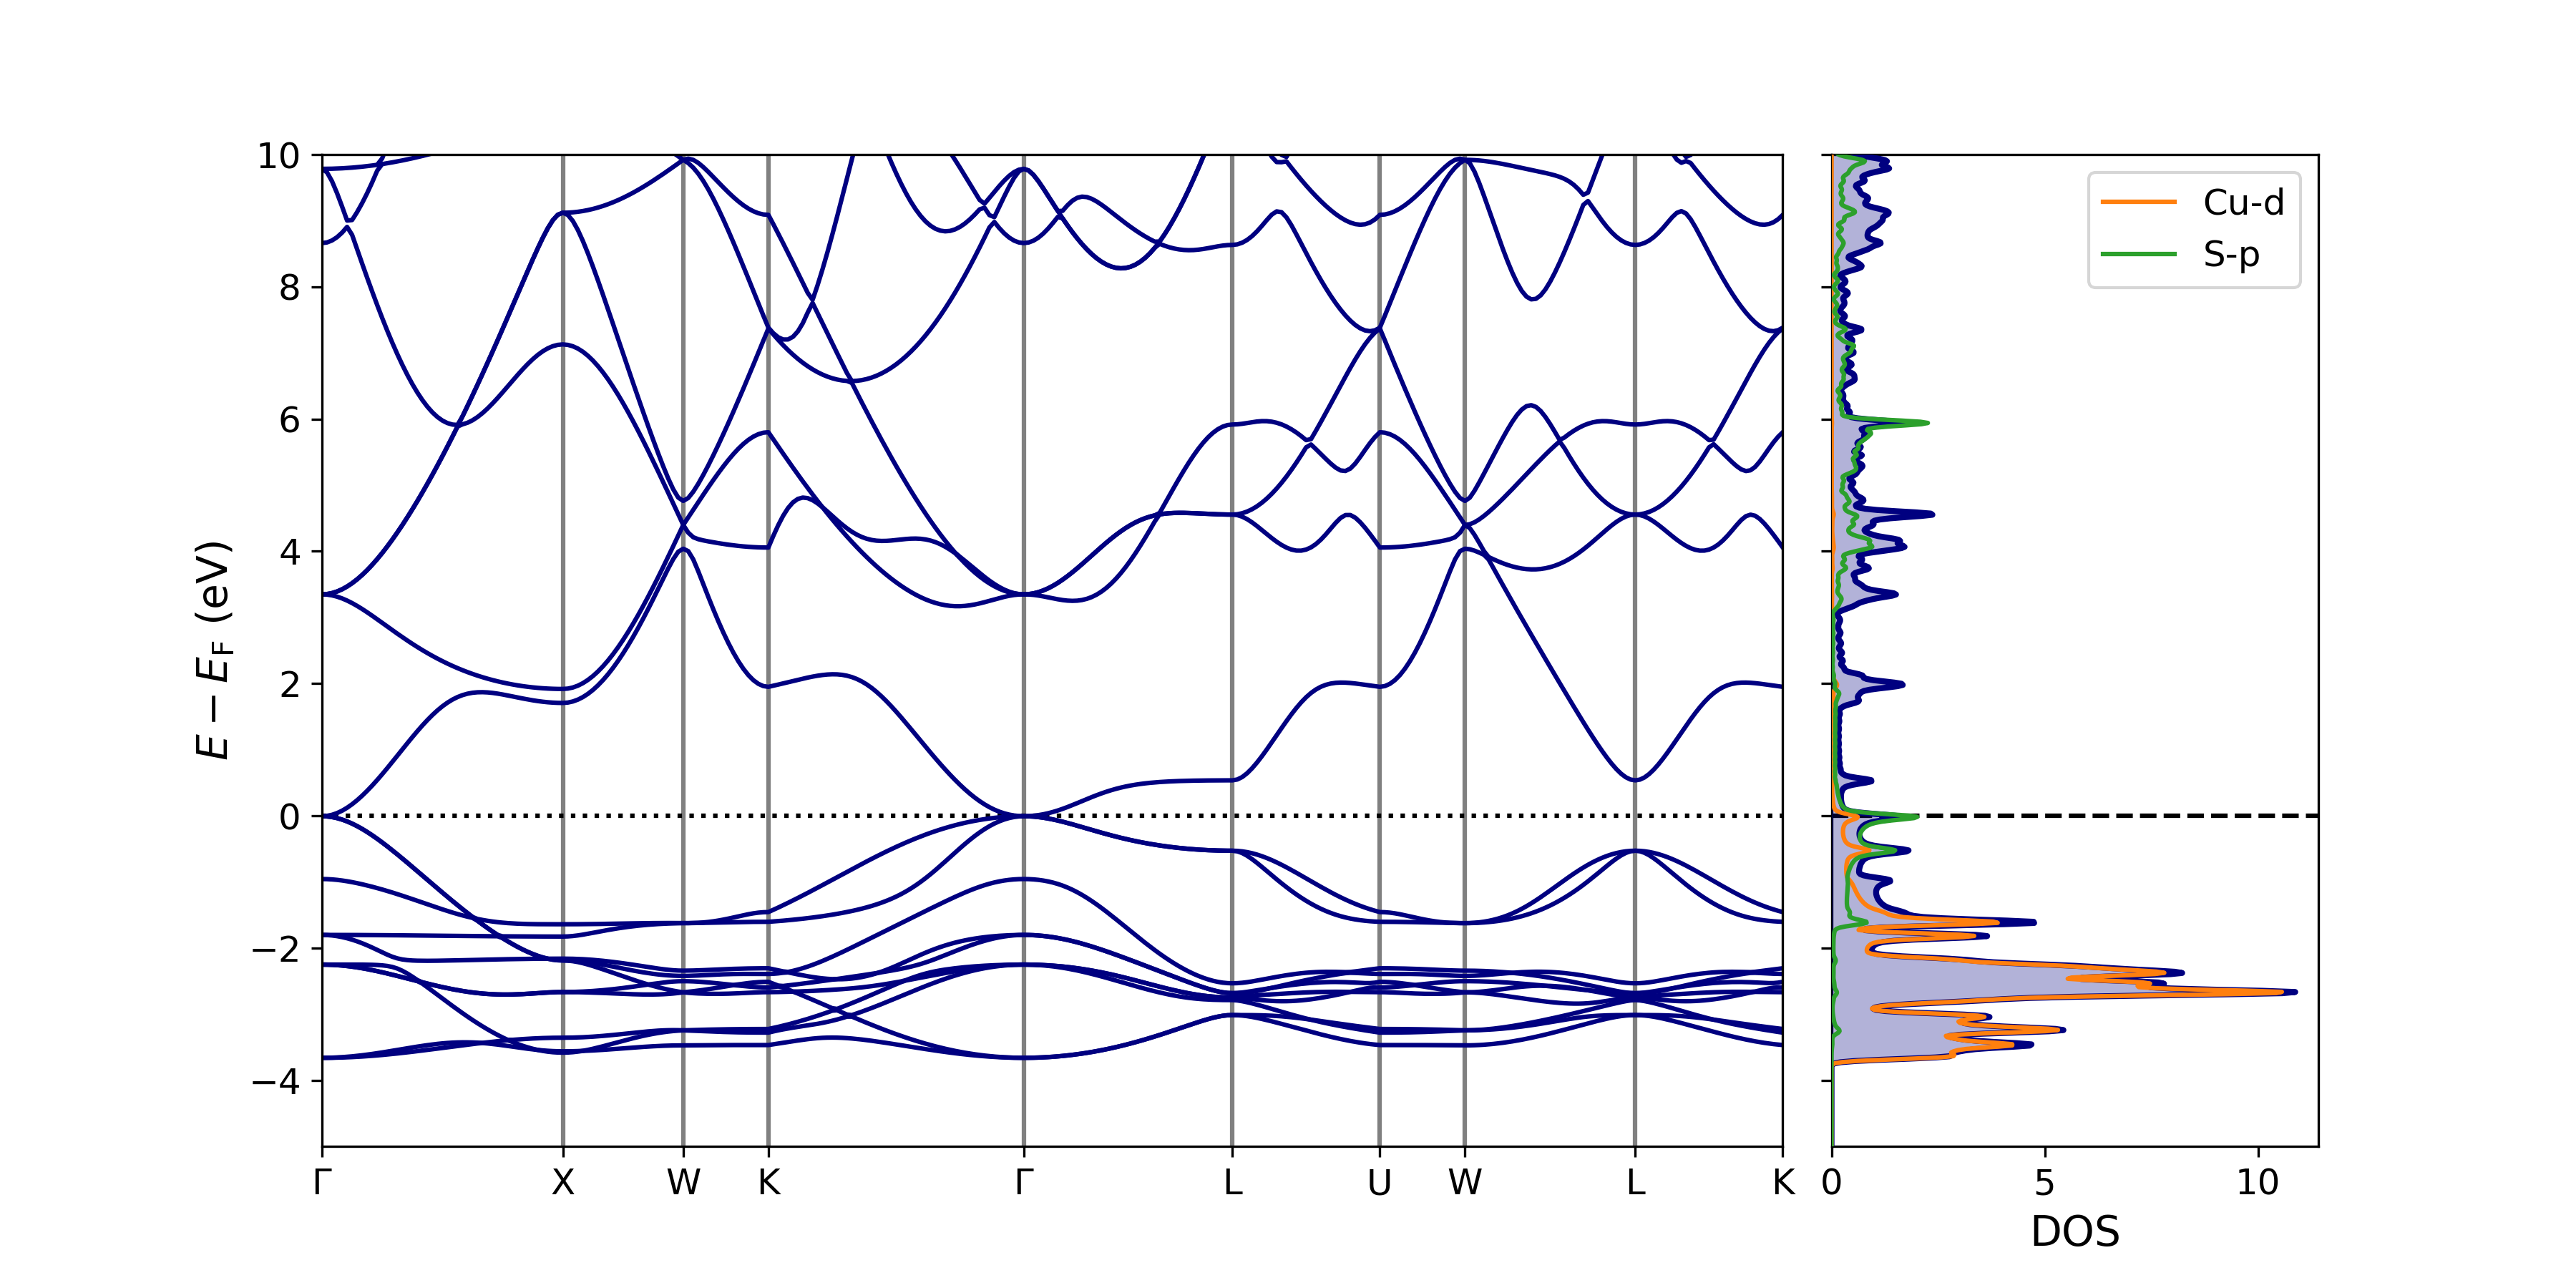

Of course this is not the right setup for trying it out on your laptops. Let's start with a minimal set up and see what we can do.

#### Tasks

1. Execute the cells below<br>
   We load the reference data and perform a minimal calculation.<br>
   To then plot a comparison.<br>
2. Perform and compare more calculations, vary<br>
   (a) k-point density<br>
   (b) energy cutoff<br>
   Which parameter has a greater effect on runtime? On quality?

In [27]:
energies_list = []
dos_total_list = []
bs_list = []
labels = []

To get a better picture of the differences, read the reference data that was plotted above and add it to the lists.

In [28]:
# read the reference calculation to plot against
import ase.io
import numpy as np
from ase.spectrum.band_structure import BandStructure

data_path = pathlib.Path.cwd().parents[1] / "data" / "presentation"

atoms = ase.io.read(data_path / "optim_cu2s.extxyz")
bs_opt = BandStructure.read(data_path / "optimal_bs.json")
data_opt = np.load(data_path / "optimal_dos.npz")
energies_opt = data_opt["energies"]
dos_total_opt = data_opt["dos_total"]

labels.append("reference")
energies_list.append(energies_opt)
dos_total_list.append(dos_total_opt)
bs_list.append(bs_opt)

In [29]:
import ase.io
from gpaw import GPAW, PW, FermiDirac
from gpaw.dos import DOSCalculator

# add a minimal calculation to the lists
atoms = ase.io.read(data_path / "optim_cu2s.extxyz")

calc_gs = GPAW(
    mode=PW(200),
    xc="PBE",
    kpts={"size": (1, 1, 1), "gamma": True},
    occupations=FermiDirac(0.01),
    txt="Cu2S_gs.txt",
)
atoms.calc = calc_gs
atoms.get_potential_energy()
calc_gs.write("Cu2S_gs.gpw")

calc_bands = GPAW("Cu2S_gs.gpw").fixed_density(
    nbands=40,
    symmetry="off",
    random=False,
    kpts={"path": "GXWKGLUWLK", "npoints": 60},
    convergence={"bands": 15},
    txt="Cu2S_bands.txt",
)

labels.append("minimal")
e, dt = calc_gs.get_dos(npts=1500, width=0.05)
energies_list.append(e)
dos_total_list.append(dt)
dos_calc = DOSCalculator.from_calculator(calc_gs)
bs = calc_bands.band_structure()
bs_list.append(bs)

To get a better idea of the differences, let's plot both calculation results together.

In [30]:
import matplotlib.pyplot as plt

def plot_bands_dos_comparison(
    bs_list,
    energies_list,
    dos_list,
    labels=None,
    colors=None,
    emin=-5,
    emax=10,
    figsize=(12, 6),
    savefig="compare_bands_and_dos.png",
    dpi=300,
):
    """
    Plot band structure + total DOS for multiple calculations.

    Parameters
    ----------
    bs_list : list[BandStructure]
        List of ASE BandStructure objects from calc_bands.band_structure().
    energies_list : list[np.ndarray]
        List of energy arrays from calc_gs.get_dos().
    dos_list : list[np.ndarray]
        List of total DOS arrays from calc_gs.get_dos().
    labels : list[str] or None
        Legend labels for each calculation.
    colors : list or None
        Colors for each calculation. If None, uses matplotlib default cycle.
    emin : float
        Lower energy bound relative to E_F in eV.
    emax : float
        Upper energy bound relative to E_F in eV.
    figsize : tuple
        Figure size.
    savefig : str or None
        Filename to save figure. None to skip saving.
    dpi : int
        Resolution for saved figure.
    """
    if labels is None:
        labels = [f"Calc {i+1}" for i in range(len(bs_list))]
    if colors is None:
        colors = [f"C{i}" for i in range(len(bs_list))]

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        sharey=True,
        gridspec_kw={"width_ratios": [3, 1], "wspace": 0.05},
        figsize=figsize,
    )

    for bs, energies, dos_total, label, color in zip(
        bs_list, energies_list, dos_list, labels, colors
    ):
        ef = bs.reference
        bs = bs.subtract_reference()
        e_shifted = energies - ef

        bs.plot(ax=ax1, color=color, label=label)
        ax2.plot(dos_total, e_shifted, color=color, lw=2, label=label)
        ax2.fill_betweenx(e_shifted, dos_total, color=color, alpha=0.2)

    ax2.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax1.set_ylabel(r"$E - E_{\mathrm{F}}$" + " (eV)", fontsize=14)
    ax1.set_ylim(emin, emax)
    ax1.tick_params(labelsize=12)
    ax2.set_xlabel("DOS", fontsize=14)
    ax2.set_xlim(0, None)
    ax2.tick_params(labelsize=12)
    ax2.legend(fontsize=12)

    ax1.get_legend().remove()

    if savefig:
        plt.savefig(savefig, dpi=dpi)
    plt.show()

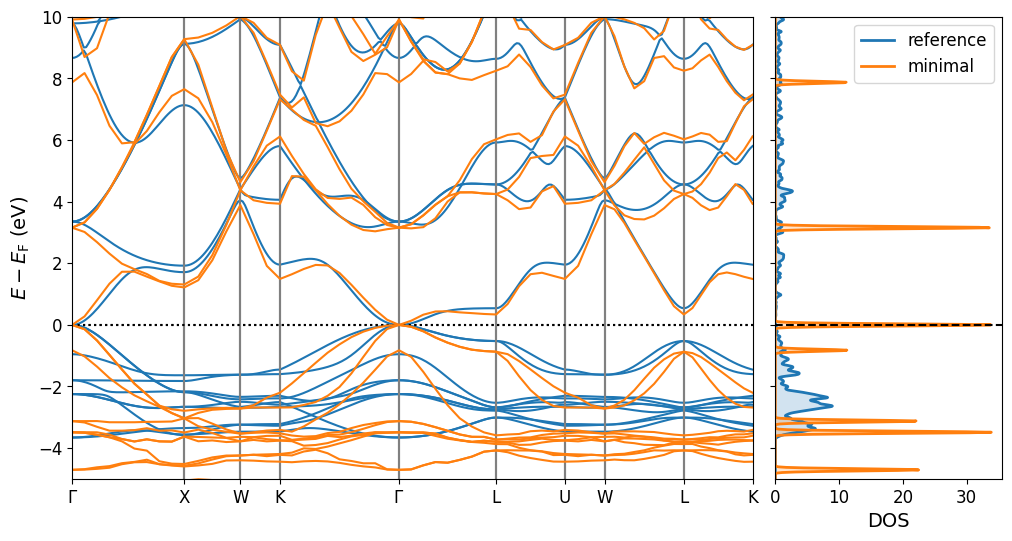

In [31]:
# you can call that function with any number of calculation results
plot_bands_dos_comparison(
    bs_list=bs_list,
    energies_list=energies_list,
    dos_list=dos_total_list,
    labels=labels,
)

---

#### Just for your reference:

The plotting script used for the original figure.

In [13]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from gpaw.dos import DOSCalculator


def plot_bands_dos(
    bs,
    energies,
    dos_total,
    emin=-5,
    emax=10,
    width=0.05,
    pdos=None,
    skip_pdos=None,
    figsize=(12, 6),
    savefig="bands_and_dos.png",
    dpi=300,
):
    """
    Plot band structure + total DOS + PDOS.

    Parameters
    ----------
    bs : BandStructure
        ASE BandStructure object from calc_bands.band_structure().
    energies : np.ndarray
        Energy array from calc_gs.get_dos().
    dos_total : np.ndarray
        Total DOS array from calc_gs.get_dos().
    emin : float
        Lower energy bound relative to E_F in eV.
    emax : float
        Upper energy bound relative to E_F in eV.
    width : float
        Gaussian broadening width in eV. Should match the width used in get_dos().
    pdos : dict or None
        Dict mapping e.g. 'Cu-d' -> np.ndarray. If None, no PDOS is plotted.
    skip_pdos : set or None
        Set of PDOS labels to exclude, e.g. {'Cu-p', 'Cu-s', 'S-s'}.
        If None, all non-negligible contributions are plotted.
    figsize : tuple
        Figure size.
    savefig : str or None
        Filename to save figure. None to skip saving.
    dpi : int
        Resolution for saved figure.
    """
    if skip_pdos is None:
        skip_pdos = set()

    # Band structure — shift to E_F
    ef = bs.reference
    bs = bs.subtract_reference()
    e_shifted = energies - ef

    # Plot
    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        sharey=True,
        gridspec_kw={"width_ratios": [3, 1], "wspace": 0.05},
        figsize=figsize,
    )

    bs.plot(ax=ax1, color="navy")
    ax1.set_ylabel(r"$E - E_{\mathrm{F}}$" + " (eV)", fontsize=14)
    ax1.set_ylim(emin, emax)
    ax1.tick_params(labelsize=12)

    ax2.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax2.plot(
        dos_total, e_shifted, color="navy", zorder=100, lw=2, label="total"
    )
    ax2.fill_betweenx(e_shifted, dos_total, color="navy", alpha=0.3, zorder=10)

    if pdos is not None:
        c = 0
        for label, dos in pdos.items():
            if label in skip_pdos:
                continue
            c += 1
            ax2.plot(
                dos, energies, label=label, c=f"C{c}", zorder=1000 + c, lw=1.5
            )

    ax2.set_xlabel("DOS", fontsize=14)
    ax2.set_xlim(0, None)
    ax2.tick_params(labelsize=12)
    plt.legend(fontsize=12)

    if savefig:
        plt.savefig(savefig, dpi=dpi)
    plt.show()

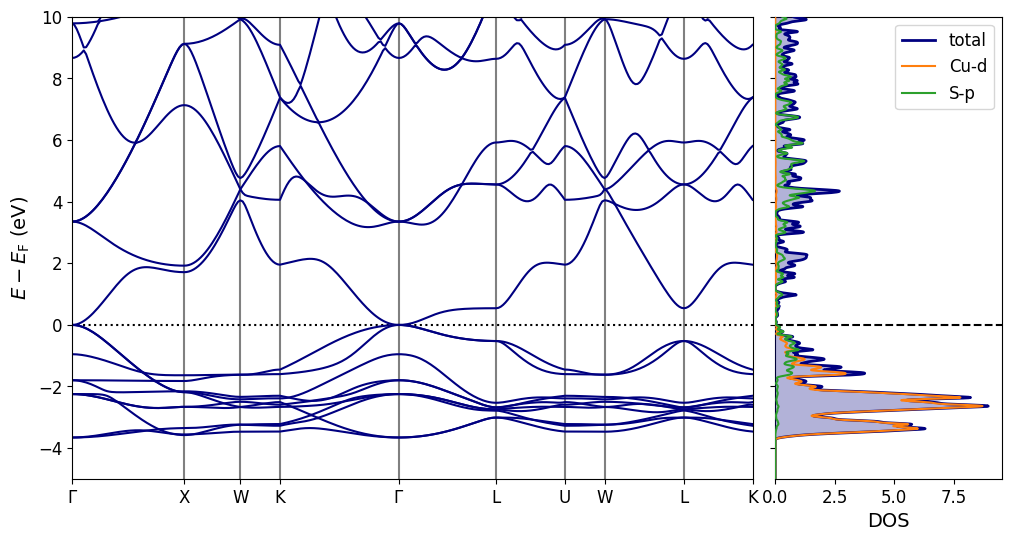

In [14]:
import ase.io
from ase.spectrum.band_structure import BandStructure

atoms = ase.io.read(data_path / "optim_cu2s.extxyz")
bs_opt = BandStructure.read(data_path / "optimal_bs.json")
data_opt = np.load(data_path / "optimal_dos.npz")
energies_opt = data_opt["energies"]
dos_total_opt = data_opt["dos_total"]
pdos_opt = {
    k: data_opt[k]
    for k in data_opt.files
    if k not in ("energies", "dos_total")
}

plot_bands_dos(
    bs=bs_opt,
    energies=energies_opt,
    dos_total=dos_total_opt,
    pdos=pdos_opt,
    skip_pdos={"Cu-p", "Cu-s", "S-s"},
)

Also, the reference calculation and PDOS code snippets.

In [15]:
# PDOS
seen = set()
pdos = defaultdict(lambda: np.zeros(len(energies_opt)))
for i, atom in enumerate(atoms):
    if atom.symbol in seen:
        continue
    seen.add(atom.symbol)
    for l, orbital in [(0, "s"), (1, "p"), (2, "d")]:
        contribution = dos_calc.raw_pdos(energies_opt, a=i, l=l, width=0.05)
        if contribution.max() > 1e-6:
            pdos[f"{atom.symbol}-{orbital}"] = contribution

In [ ]:
# bs & dos with original settings - click to expand

import ase.io
from gpaw import GPAW, PW, FermiDirac

# here you can also point to your own optimized structure instead
data_path = pathlib.Path.cwd().parents[1] / "data" / "GPAW_basics"
atoms = ase.io.read(data_path / "optim_cu2s.extxyz")

calc_gs = GPAW(
    mode=PW(800),
    xc="PBE",
    kpts={"size": (12, 12, 12), "gamma": True},
    occupations=FermiDirac(0.01),
    txt="Cu2S_gs.txt",
)
atoms.calc = calc_gs
atoms.get_potential_energy()
calc_gs.write("Cu2S_gs.gpw")

calc_bands = GPAW("Cu2S_gs.gpw").fixed_density(
    nbands=40,
    symmetry="off",
    random=False,
    kpts={"path": "GXWKGLUWLK", "npoints": 300},
    convergence={"bands": 30},
    txt="Cu2S_bands.txt",
)
energies_ref, dos_total_ref = calc_gs.get_dos(npts=3000, width=0.05)
dos_calc_ref = DOSCalculator.from_calculator(calc_gs)
bs_ref = calc_bands.band_structure()